<a href="https://colab.research.google.com/github/sadasivam009/bike-sharing-demand-reg-/blob/main/CLUS_%5BOnline_Retail_Dataset%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Online Retail Dataset**

 CLUSTERING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('/content/sample_data/archive (5).zip')

In [3]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
x = df.iloc[:,:]

In [20]:
pca = PCA(n_components=2,random_state=42)
X_pca = pca.fit_transform(numerical_features)

In [21]:
X_pca

array([[-3.55084259, -2.06353657],
       [-3.55141565, -1.22353676],
       [-1.5509795 , -1.86217217],
       ...,
       [-5.55193367, -0.46490138],
       [-5.55193367, -0.46490138],
       [-6.55247922,  0.33441621]])

In [22]:
pca.explained_variance_ratio_.cumsum()[1]

np.float64(1.0)

In [23]:
distortion = []
for i in range(1,5):
  km = KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=5)
  km.fit(X_pca)
  distortion.append(km.inertia_)

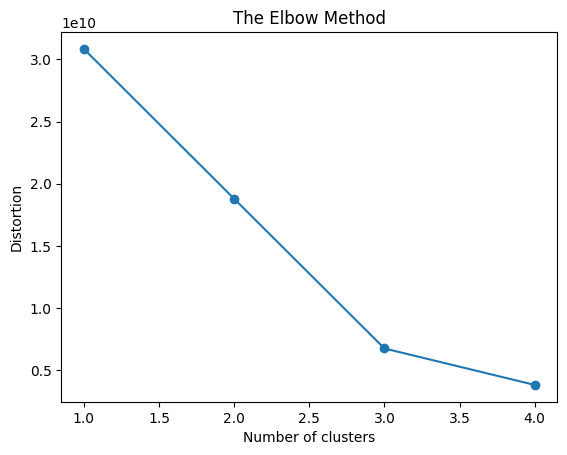

In [24]:
plt.plot(range(1,5),distortion,marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

In [25]:
model = KMeans(n_clusters=3,init='k-means++',random_state=42,n_init=5)
model.fit(X_pca)

KMeans(n_clusters=3, n_init=5, random_state=42)

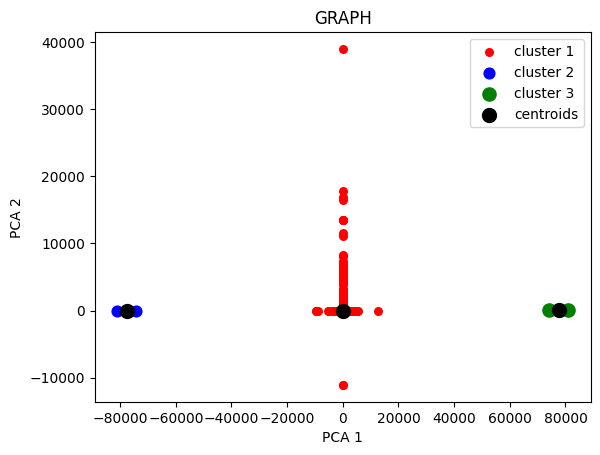

In [28]:
y = model.labels_
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=30,c='red',label='cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=60,c='blue',label='cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=90,c='green',label='cluster 3')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='black',label='centroids')
plt.legend()
plt.title('GRAPH')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()